# Eigenfaces: Face Recognition using PCA — Improved Version

**Project:** Applying Principal Component Analysis to a Real-World Problem  
**Dataset:** Olivetti Faces (AT&T Laboratories Cambridge)  
**Reference:** Turk, M., & Pentland, A. (1991). Eigenfaces for recognition. *Journal of Cognitive Neuroscience*, 3(1), 71-86.

## Objectives
1. Apply PCA to a high-dimensional image dataset
2. Visualize and interpret the principal components (eigenfaces)
3. Analyze variance explained and reconstruction quality
4. Build a face recognition classifier using PCA features
5. Evaluate performance with **cross-validation** and **hyperparameter tuning**
6. Compare PCA against the classical **Fisherfaces (PCA + LDA)** extension
7. Discuss limitations and when each method wins

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  
import seaborn as sns
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_recall_fscore_support
)
import time
import os

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot styling
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

# Output directory for saving figures (Kaggle persistent path)
OUTPUT_DIR = '/kaggle/working' if os.path.exists('/kaggle/working') else '.'
print(f'Output directory: {OUTPUT_DIR}')
print('Libraries loaded successfully.')

Output directory: /kaggle/working
Libraries loaded successfully.


## 2. Load and Explore the Dataset

The Olivetti Faces dataset contains **400 grayscale images** of **40 distinct subjects** (10 images per person). Each image is 64×64 pixels = **4096 features per sample**.

Variations include: lighting, facial expressions (open/closed eyes, smiling/not), and facial details (glasses/no glasses).

In [2]:
# Load dataset (downloads ~7MB on first run, then cached)
data = fetch_olivetti_faces(shuffle=True, random_state=RANDOM_STATE)
X = data.data           
X_images = data.images  
y = data.target         

n_samples, n_features = X.shape
n_classes = len(np.unique(y))
h, w = X_images.shape[1], X_images.shape[2]

print(f'Number of samples : {n_samples}')
print(f'Number of features: {n_features} ({h}x{w} pixels)')
print(f'Number of classes : {n_classes} subjects')
print(f'Samples per class : {n_samples // n_classes}')
print(f'Pixel value range : [{X.min():.3f}, {X.max():.3f}]')

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Number of samples : 400
Number of features: 4096 (64x64 pixels)
Number of classes : 40 subjects
Samples per class : 10
Pixel value range : [0.000, 1.000]


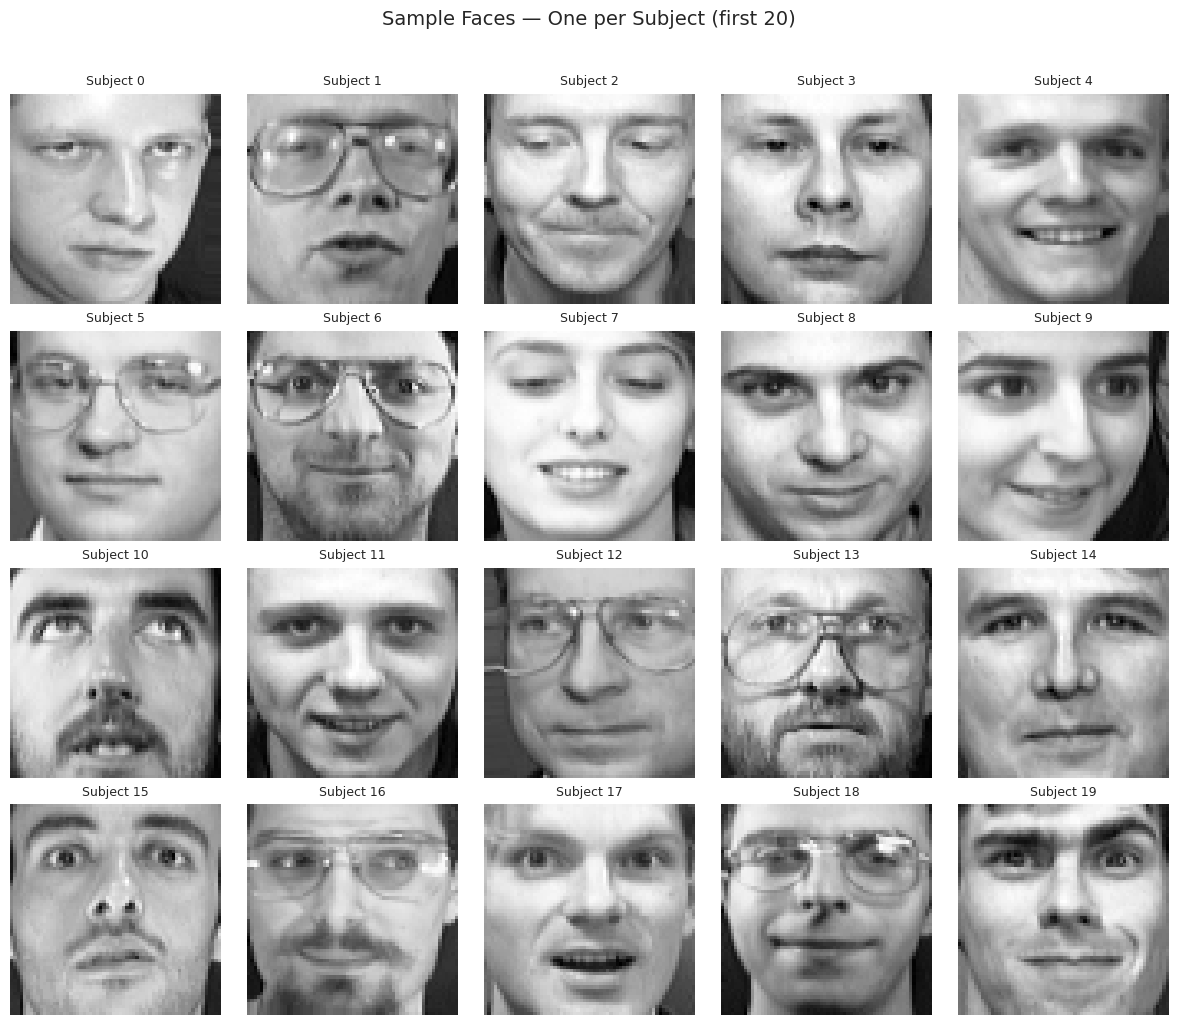

In [3]:
# Visualize sample faces — one per subject for the first 20 subjects
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
for i, ax in enumerate(axes.flat):
    idx = np.where(y == i)[0][0]
    ax.imshow(X_images[idx], cmap='gray')
    ax.set_title(f'Subject {i}', fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Faces — One per Subject (first 20)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_sample_faces.png', dpi=150, bbox_inches='tight')
plt.show()

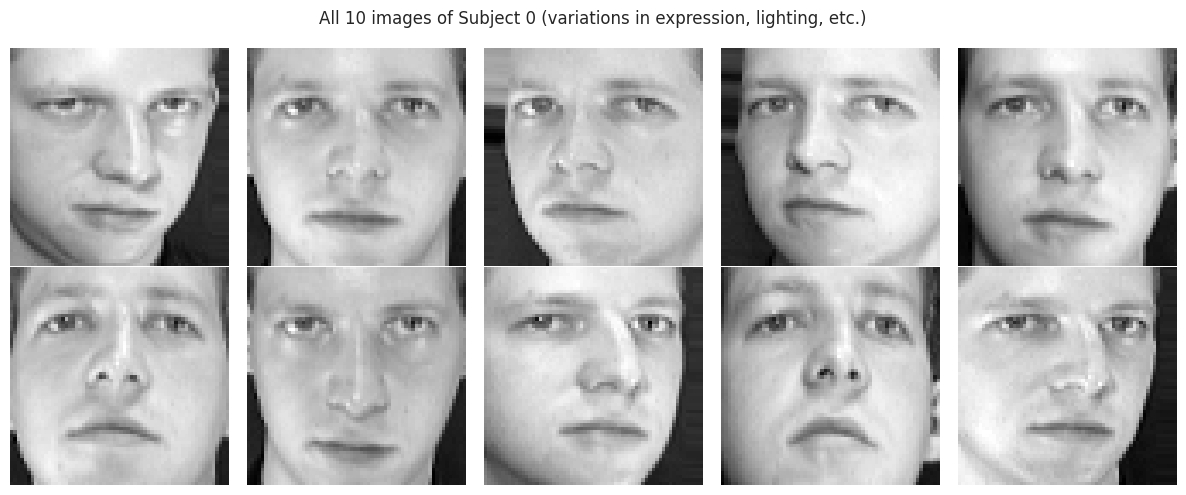

In [4]:
# Visualize the 10 images of a single subject — shows intra-class variability
subject_id = 0
indices = np.where(y == subject_id)[0]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_images[idx], cmap='gray')
    ax.axis('off')
plt.suptitle(f'All 10 images of Subject {subject_id} (variations in expression, lighting, etc.)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_intra_class_variability.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Train/Test Split

We use **stratified sampling** to ensure every subject appears in both training and test sets.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set    : {X_test.shape[0]} samples')
print(f'Per-class training examples: {X_train.shape[0] // n_classes} (avg)')

Training set: 300 samples
Test set    : 100 samples
Per-class training examples: 7 (avg)


## 4. Apply PCA

PCA finds an orthonormal basis where the data has maximum variance along each successive axis. For face images, the principal components are themselves images — the **eigenfaces**.

**Mathematical recap:**
1. Center the data: $\tilde{X} = X - \bar{X}$
2. Compute covariance: $C = \frac{1}{n-1}\tilde{X}^T \tilde{X}$
3. Eigendecompose: $C v_i = \lambda_i v_i$
4. The eigenvectors $v_i$ (sorted by decreasing $\lambda_i$) are the principal components.

In [6]:
n_components_full = min(X_train.shape[0], X_train.shape[1])
pca_full = PCA(n_components=n_components_full, whiten=False, random_state=RANDOM_STATE)

t0 = time.time()
pca_full.fit(X_train)
fit_time = time.time() - t0

print(f'PCA fitted in {fit_time:.2f} seconds.')
print(f'Total components computed: {pca_full.n_components_}')

PCA fitted in 0.19 seconds.
Total components computed: 300


## 5. Variance Analysis (Scree Plot)

In [7]:
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

thresholds = [0.80, 0.90, 0.95, 0.99]
components_needed = {t: int(np.argmax(cumulative >= t)) + 1 for t in thresholds}

print('Components needed to retain X% of variance:')
for t, k in components_needed.items():
    print(f'  {int(t*100)}%: {k} components ({k/n_features*100:.1f}% of original dimensions)')

Components needed to retain X% of variance:
  80%: 26 components (0.6% of original dimensions)
  90%: 62 components (1.5% of original dimensions)
  95%: 109 components (2.7% of original dimensions)
  99%: 211 components (5.2% of original dimensions)


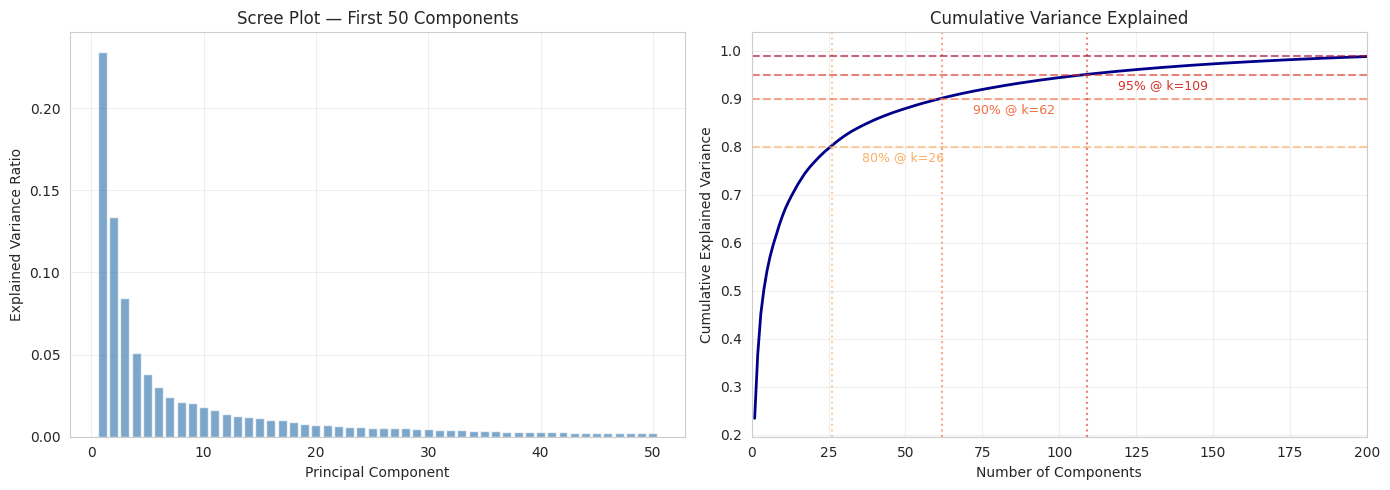

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

k_show = 50
axes[0].bar(range(1, k_show + 1), explained[:k_show], alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title(f'Scree Plot — First {k_show} Components')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(cumulative) + 1), cumulative, color='darkblue', linewidth=2)
for t, color in zip(thresholds, ['#fdae61', '#f46d43', '#d73027', '#a50026']):
    k = components_needed[t]
    axes[1].axhline(t, color=color, linestyle='--', alpha=0.6)
    axes[1].axvline(k, color=color, linestyle=':', alpha=0.6)
    axes[1].annotate(f'{int(t*100)}% @ k={k}', xy=(k, t), xytext=(k+10, t-0.03),
                     fontsize=9, color=color)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xlim(0, 200)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_scree_and_cumulative.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The first few components capture most of the variance. Beyond ~150 components we see diminishing returns — 4096 raw pixel dimensions can be compressed to ~100 meaningful directions with minimal information loss.

## 6. Visualizing the Eigenfaces

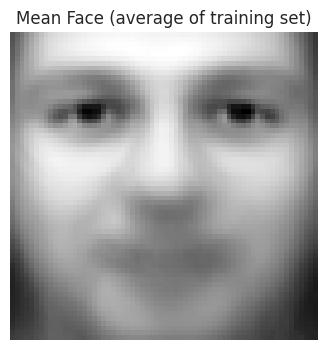

In [9]:
mean_face = pca_full.mean_.reshape(h, w)

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(mean_face, cmap='gray')
ax.set_title('Mean Face (average of training set)')
ax.axis('off')
plt.savefig(f'{OUTPUT_DIR}/04_mean_face.png', dpi=150, bbox_inches='tight')
plt.show()

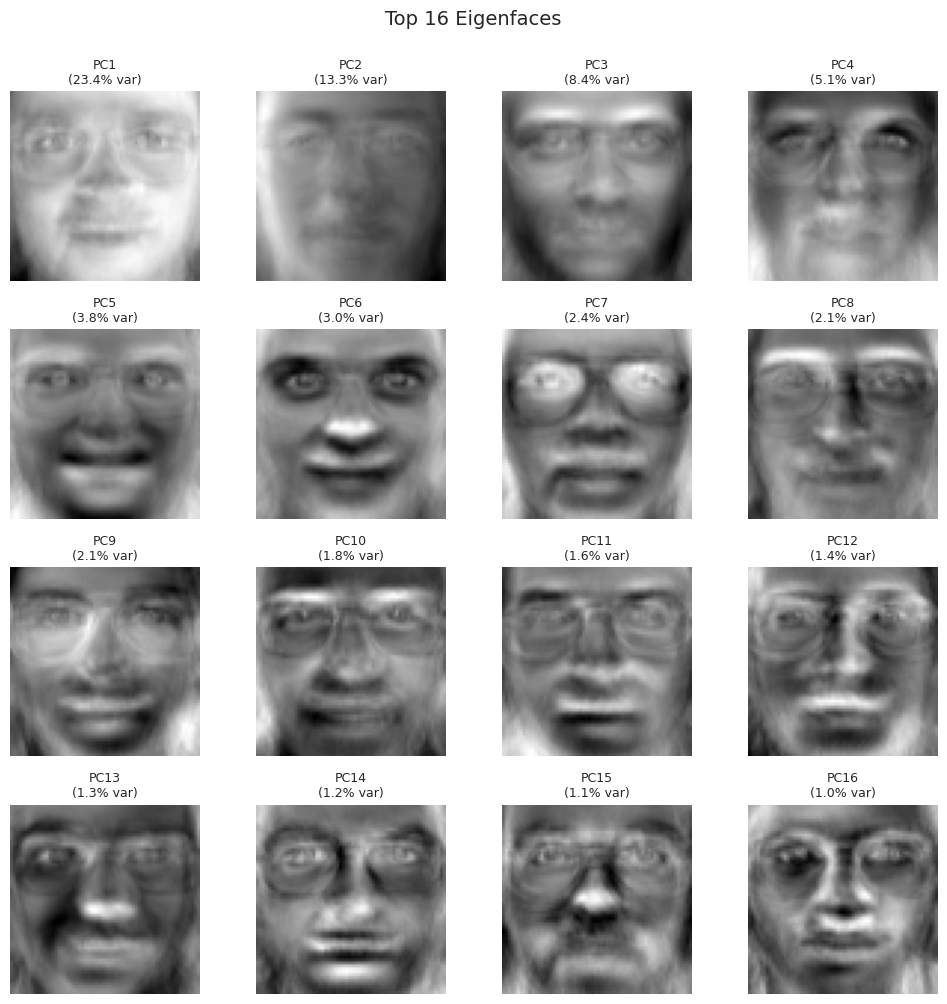

In [10]:
n_eigenfaces_show = 16
eigenfaces = pca_full.components_.reshape((-1, h, w))

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(eigenfaces[i], cmap='gray')
    ax.set_title(f'PC{i+1}\n({explained[i]*100:.1f}% var)', fontsize=9)
    ax.axis('off')
plt.suptitle('Top 16 Eigenfaces', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_eigenfaces.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Reconstruction Quality vs Number of Components

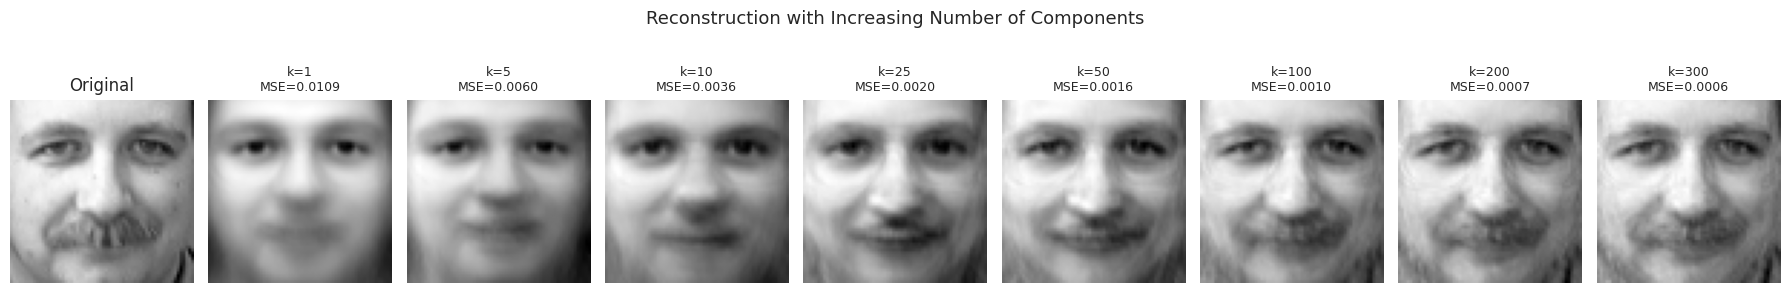

In [11]:
test_face = X_test[0]
ks = [1, 5, 10, 25, 50, 100, 200, 300]

fig, axes = plt.subplots(1, len(ks) + 1, figsize=(18, 3))
axes[0].imshow(test_face.reshape(h, w), cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

for ax, k in zip(axes[1:], ks):
    pca_k = PCA(n_components=k, random_state=RANDOM_STATE).fit(X_train)
    reconstructed = pca_k.inverse_transform(pca_k.transform(test_face.reshape(1, -1)))
    mse = np.mean((test_face - reconstructed.flatten())**2)
    ax.imshow(reconstructed.reshape(h, w), cmap='gray')
    ax.set_title(f'k={k}\nMSE={mse:.4f}', fontsize=9)
    ax.axis('off')
plt.suptitle('Reconstruction with Increasing Number of Components', fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_reconstruction_examples.png', dpi=150, bbox_inches='tight')
plt.show()

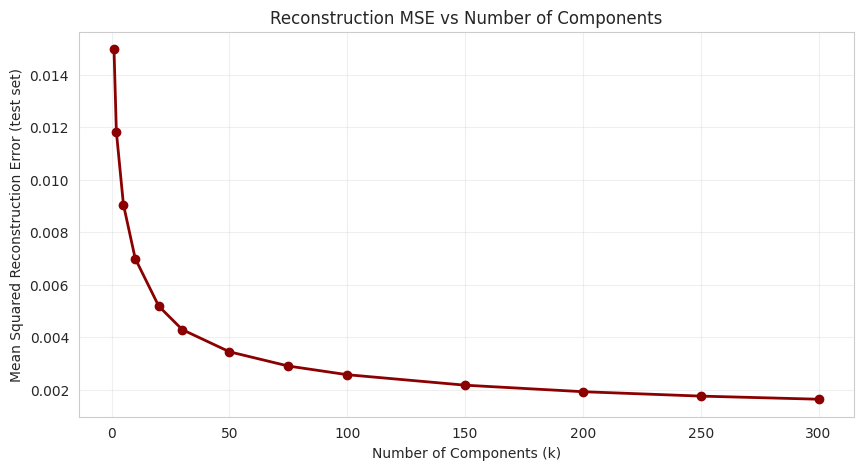

In [12]:
k_values = [1, 2, 5, 10, 20, 30, 50, 75, 100, 150, 200, 250, 300]
mse_curve = []

for k in k_values:
    pca_k = PCA(n_components=k, random_state=RANDOM_STATE).fit(X_train)
    X_test_recon = pca_k.inverse_transform(pca_k.transform(X_test))
    mse_curve.append(np.mean((X_test - X_test_recon)**2))

plt.figure(figsize=(10, 5))
plt.plot(k_values, mse_curve, marker='o', color='darkred', linewidth=2)
plt.xlabel('Number of Components (k)')
plt.ylabel('Mean Squared Reconstruction Error (test set)')
plt.title('Reconstruction MSE vs Number of Components')
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/07_reconstruction_mse_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 2D and 3D Projection of the Faces

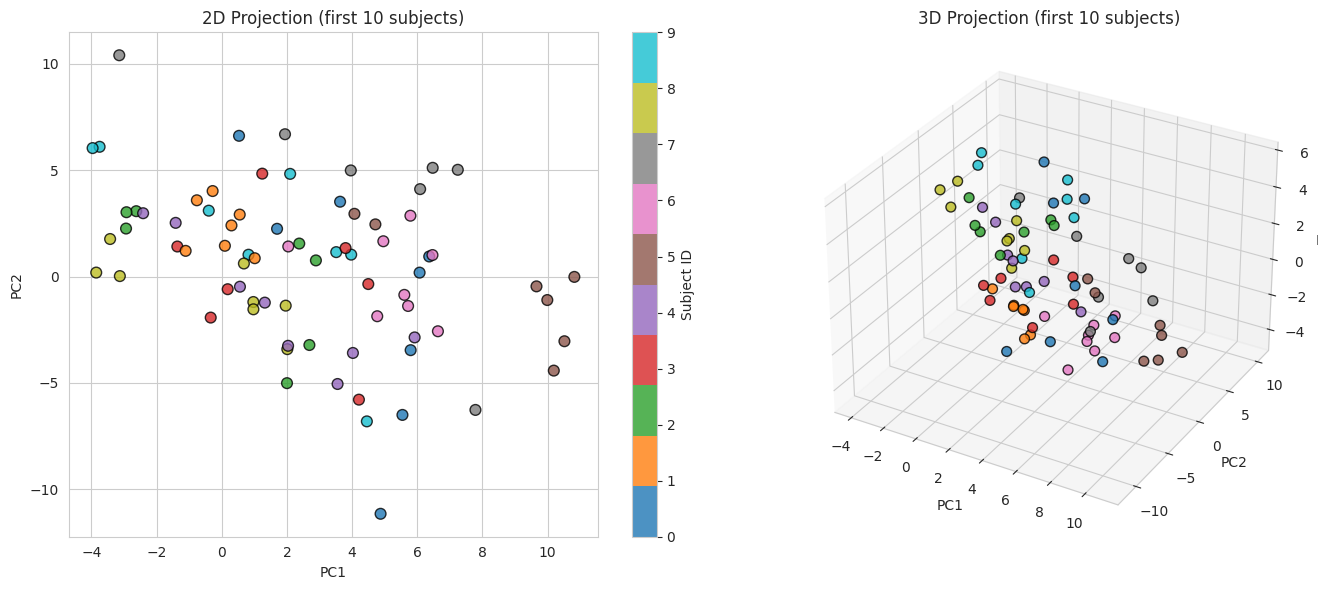

In [13]:
pca_3 = PCA(n_components=3, random_state=RANDOM_STATE).fit(X_train)
X_train_3d = pca_3.transform(X_train)

n_show = 10
mask = y_train < n_show

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1)
scatter = ax1.scatter(X_train_3d[mask, 0], X_train_3d[mask, 1],
                      c=y_train[mask], cmap='tab10', s=60, alpha=0.8, edgecolors='k')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title(f'2D Projection (first {n_show} subjects)')
plt.colorbar(scatter, ax=ax1, label='Subject ID')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(X_train_3d[mask, 0], X_train_3d[mask, 1], X_train_3d[mask, 2],
            c=y_train[mask], cmap='tab10', s=50, alpha=0.8, edgecolors='k')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')
ax2.set_title(f'3D Projection (first {n_show} subjects)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_2d_3d_projection.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Face Recognition: Classification on PCA Features

We now use the PCA-reduced features as input to a classifier. We test two approaches and sweep over the number of components.

In [14]:
k_sweep = [5, 10, 20, 30, 50, 75, 100, 150, 200]
results = {'k': [], 'knn_acc': [], 'svm_acc': [], 'knn_time': [], 'svm_time': []}

for k in k_sweep:
    pca_k = PCA(n_components=k, whiten=True, random_state=RANDOM_STATE).fit(X_train)
    X_train_pca = pca_k.transform(X_train)
    X_test_pca = pca_k.transform(X_test)

    t0 = time.time()
    knn = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
    knn.fit(X_train_pca, y_train)
    knn_acc = accuracy_score(y_test, knn.predict(X_test_pca))
    knn_time = time.time() - t0

    t0 = time.time()
    svm = SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE)
    svm.fit(X_train_pca, y_train)
    svm_acc = accuracy_score(y_test, svm.predict(X_test_pca))
    svm_time = time.time() - t0

    results['k'].append(k)
    results['knn_acc'].append(knn_acc)
    results['svm_acc'].append(svm_acc)
    results['knn_time'].append(knn_time)
    results['svm_time'].append(svm_time)
    print(f'k={k:>4}  |  k-NN: {knn_acc:.3f}  |  SVM: {svm_acc:.3f}  |  k-NN time: {knn_time:.3f}s  SVM time: {svm_time:.3f}s')

k=   5  |  k-NN: 0.660  |  SVM: 0.660  |  k-NN time: 0.014s  SVM time: 0.042s
k=  10  |  k-NN: 0.880  |  SVM: 0.870  |  k-NN time: 0.005s  SVM time: 0.025s
k=  20  |  k-NN: 0.970  |  SVM: 0.960  |  k-NN time: 0.102s  SVM time: 0.033s
k=  30  |  k-NN: 0.960  |  SVM: 0.930  |  k-NN time: 0.008s  SVM time: 0.056s
k=  50  |  k-NN: 0.930  |  SVM: 0.960  |  k-NN time: 0.014s  SVM time: 0.047s
k=  75  |  k-NN: 0.950  |  SVM: 0.980  |  k-NN time: 0.007s  SVM time: 0.039s
k= 100  |  k-NN: 0.920  |  SVM: 0.980  |  k-NN time: 0.008s  SVM time: 0.042s
k= 150  |  k-NN: 0.860  |  SVM: 0.970  |  k-NN time: 0.014s  SVM time: 0.053s
k= 200  |  k-NN: 0.790  |  SVM: 0.980  |  k-NN time: 0.006s  SVM time: 0.042s


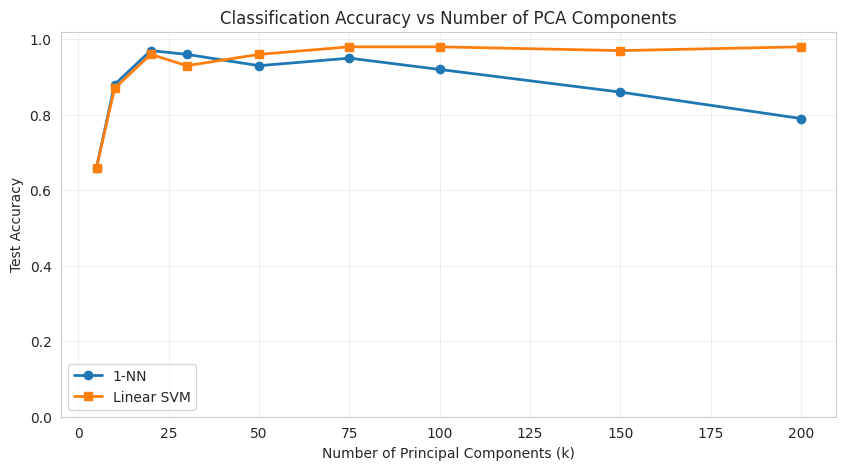

Best k for 1-NN : 20 (accuracy = 0.970)
Best k for SVM  : 75 (accuracy = 0.980)


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results['k'], results['knn_acc'], marker='o', linewidth=2, label='1-NN')
ax.plot(results['k'], results['svm_acc'], marker='s', linewidth=2, label='Linear SVM')
ax.set_xlabel('Number of Principal Components (k)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Classification Accuracy vs Number of PCA Components')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.02)
plt.savefig(f'{OUTPUT_DIR}/09_accuracy_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

best_k_knn = results['k'][int(np.argmax(results['knn_acc']))]
best_k_svm = results['k'][int(np.argmax(results['svm_acc']))]
print(f'Best k for 1-NN : {best_k_knn} (accuracy = {max(results["knn_acc"]):.3f})')
print(f'Best k for SVM  : {best_k_svm} (accuracy = {max(results["svm_acc"]):.3f})')

## 10. Detailed Evaluation at the Best k

In [16]:
best_k = best_k_svm
pca_best = PCA(n_components=best_k, whiten=True, random_state=RANDOM_STATE).fit(X_train)
X_train_best = pca_best.transform(X_train)
X_test_best = pca_best.transform(X_test)

best_clf = SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE)
best_clf.fit(X_train_best, y_train)
y_pred = best_clf.predict(X_test_best)

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)

print(f'Best configuration: PCA(k={best_k}) + Linear SVM\n')
print(f'Accuracy        : {acc:.4f}')
print(f'Precision (macro): {prec:.4f}')
print(f'Recall    (macro): {rec:.4f}')
print(f'F1-score  (macro): {f1:.4f}')
print(f'\nDimensionality reduction: {n_features} -> {best_k} ({best_k/n_features*100:.1f}% of original)')

Best configuration: PCA(k=75) + Linear SVM

Accuracy        : 0.9800
Precision (macro): 0.9875
Recall    (macro): 0.9833
F1-score  (macro): 0.9829

Dimensionality reduction: 4096 -> 75 (1.8% of original)


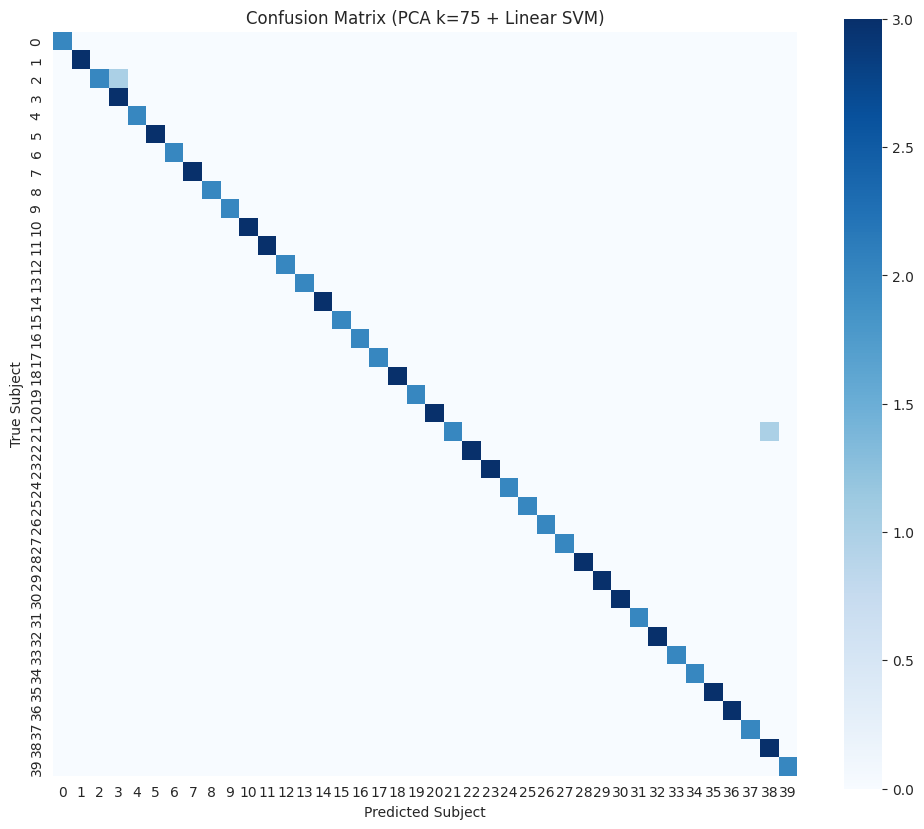

In [17]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', cbar=True, square=True)
plt.xlabel('Predicted Subject')
plt.ylabel('True Subject')
plt.title(f'Confusion Matrix (PCA k={best_k} + Linear SVM)')
plt.savefig(f'{OUTPUT_DIR}/10_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Baseline Comparison: Raw Pixels (No PCA)

In [18]:
t0 = time.time()
knn_raw = KNeighborsClassifier(n_neighbors=1).fit(X_train, y_train)
knn_raw_acc = accuracy_score(y_test, knn_raw.predict(X_test))
knn_raw_time = time.time() - t0

t0 = time.time()
svm_raw = SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE).fit(X_train, y_train)
svm_raw_acc = accuracy_score(y_test, svm_raw.predict(X_test))
svm_raw_time = time.time() - t0

print('=' * 60)
print(f'{"Method":<35} {"Accuracy":<12} {"Time (s)":<10}')
print('=' * 60)
print(f'{"1-NN on raw pixels (4096-dim)":<35} {knn_raw_acc:<12.4f} {knn_raw_time:<10.3f}')
print(f'{"SVM on raw pixels (4096-dim)":<35} {svm_raw_acc:<12.4f} {svm_raw_time:<10.3f}')
print(f'{f"1-NN on PCA (k={best_k_knn})":<35} {max(results["knn_acc"]):<12.4f}')
print(f'{f"SVM on PCA (k={best_k_svm})":<35} {max(results["svm_acc"]):<12.4f}')
print('=' * 60)

Method                              Accuracy     Time (s)  
1-NN on raw pixels (4096-dim)       0.9400       0.032     
SVM on raw pixels (4096-dim)        0.9700       0.294     
1-NN on PCA (k=20)                  0.9700      
SVM on PCA (k=75)                   0.9800      


## 12. Robustness Test: Recognition under Noise

sigma=0.00  |  PCA+SVM: 0.980  |  Raw SVM: 0.970
sigma=0.05  |  PCA+SVM: 0.970  |  Raw SVM: 0.970
sigma=0.10  |  PCA+SVM: 0.970  |  Raw SVM: 0.970
sigma=0.15  |  PCA+SVM: 0.970  |  Raw SVM: 0.970
sigma=0.20  |  PCA+SVM: 0.950  |  Raw SVM: 0.970
sigma=0.30  |  PCA+SVM: 0.930  |  Raw SVM: 0.940
sigma=0.40  |  PCA+SVM: 0.880  |  Raw SVM: 0.870


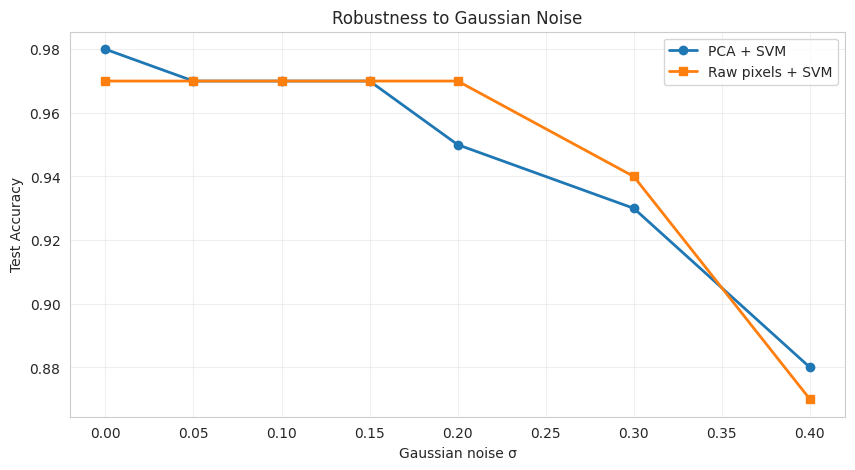

In [19]:
noise_levels = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]
noise_results = {'sigma': [], 'acc_pca': [], 'acc_raw': []}

for sigma in noise_levels:
    np.random.seed(RANDOM_STATE)
    X_test_noisy = X_test + np.random.normal(0, sigma, X_test.shape)
    X_test_noisy = np.clip(X_test_noisy, 0, 1)

    X_test_noisy_pca = pca_best.transform(X_test_noisy)
    acc_pca = accuracy_score(y_test, best_clf.predict(X_test_noisy_pca))
    acc_raw = accuracy_score(y_test, svm_raw.predict(X_test_noisy))

    noise_results['sigma'].append(sigma)
    noise_results['acc_pca'].append(acc_pca)
    noise_results['acc_raw'].append(acc_raw)
    print(f'sigma={sigma:.2f}  |  PCA+SVM: {acc_pca:.3f}  |  Raw SVM: {acc_raw:.3f}')

plt.figure(figsize=(10, 5))
plt.plot(noise_results['sigma'], noise_results['acc_pca'], marker='o', linewidth=2, label='PCA + SVM')
plt.plot(noise_results['sigma'], noise_results['acc_raw'], marker='s', linewidth=2, label='Raw pixels + SVM')
plt.xlabel('Gaussian noise σ')
plt.ylabel('Test Accuracy')
plt.title('Robustness to Gaussian Noise')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/11_robustness_noise.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Visualizing Predictions

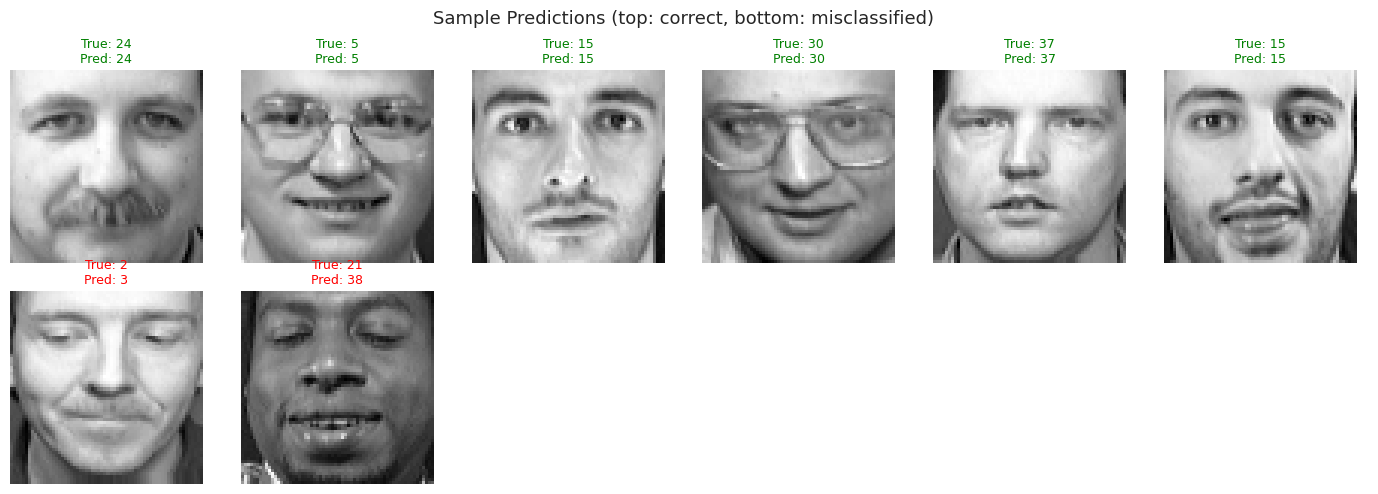

In [20]:
correct_idx = np.where(y_pred == y_test)[0][:6]
wrong_idx = np.where(y_pred != y_test)[0][:6]

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i, idx in enumerate(correct_idx):
    axes[0, i].imshow(X_test[idx].reshape(h, w), cmap='gray')
    axes[0, i].set_title(f'True: {y_test[idx]}\nPred: {y_pred[idx]}', fontsize=9, color='green')
    axes[0, i].axis('off')

if len(wrong_idx) > 0:
    for i, idx in enumerate(wrong_idx):
        axes[1, i].imshow(X_test[idx].reshape(h, w), cmap='gray')
        axes[1, i].set_title(f'True: {y_test[idx]}\nPred: {y_pred[idx]}', fontsize=9, color='red')
        axes[1, i].axis('off')
    for j in range(len(wrong_idx), 6):
        axes[1, j].axis('off')
else:
    for j in range(6):
        axes[1, j].axis('off')
    axes[1, 2].text(0.5, 0.5, 'No misclassifications!', ha='center', va='center', fontsize=12, color='green')

plt.suptitle('Sample Predictions (top: correct, bottom: misclassified)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/12_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Improvements Section

The previous sections evaluated the model on a single train/test split with default hyperparameters. To make the results more rigorous, we now add three improvements:

1. **k-fold cross-validation** — gives mean ± std accuracy instead of a single point estimate
2. **GridSearchCV** — jointly tunes the number of components and SVM hyperparameters
3. **Fisherfaces (PCA + LDA)** — the academic follow-up to Eigenfaces, which finds directions of maximum class separability rather than maximum variance
---

## 14. Cross-Validation: How Robust is Our 98%?

A single train/test split can be lucky or unlucky. We use **5-fold stratified cross-validation** to estimate the true expected accuracy with confidence bounds. We use the *full* dataset since CV creates internal splits.

We use a `Pipeline` so the PCA fit happens **inside** each fold — no information leakage from validation data.

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

configs = [
    ('PCA(k=20) + 1-NN', Pipeline([
        ('pca', PCA(n_components=20, whiten=True, random_state=RANDOM_STATE)),
        ('clf', KNeighborsClassifier(n_neighbors=1)),
    ])),
    ('PCA(k=75) + Linear SVM', Pipeline([
        ('pca', PCA(n_components=75, whiten=True, random_state=RANDOM_STATE)),
        ('clf', SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE)),
    ])),
    ('PCA(k=100) + Linear SVM', Pipeline([
        ('pca', PCA(n_components=100, whiten=True, random_state=RANDOM_STATE)),
        ('clf', SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE)),
    ])),
    ('Raw pixels + Linear SVM', Pipeline([
        ('clf', SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE)),
    ])),
]

cv_results = {}
for name, pipeline in configs:
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<30}  {scores.mean():.4f} ± {scores.std():.4f}  '
          f'(folds: {[f"{s:.3f}" for s in scores]})')

PCA(k=20) + 1-NN                0.9525 ± 0.0166  (folds: ['0.963', '0.975', '0.950', '0.950', '0.925'])
PCA(k=75) + Linear SVM          0.9725 ± 0.0122  (folds: ['0.963', '0.988', '0.963', '0.963', '0.988'])
PCA(k=100) + Linear SVM         0.9725 ± 0.0184  (folds: ['0.963', '0.988', '0.963', '1.000', '0.950'])
Raw pixels + Linear SVM         0.9700 ± 0.0170  (folds: ['0.963', '0.975', '1.000', '0.963', '0.950'])


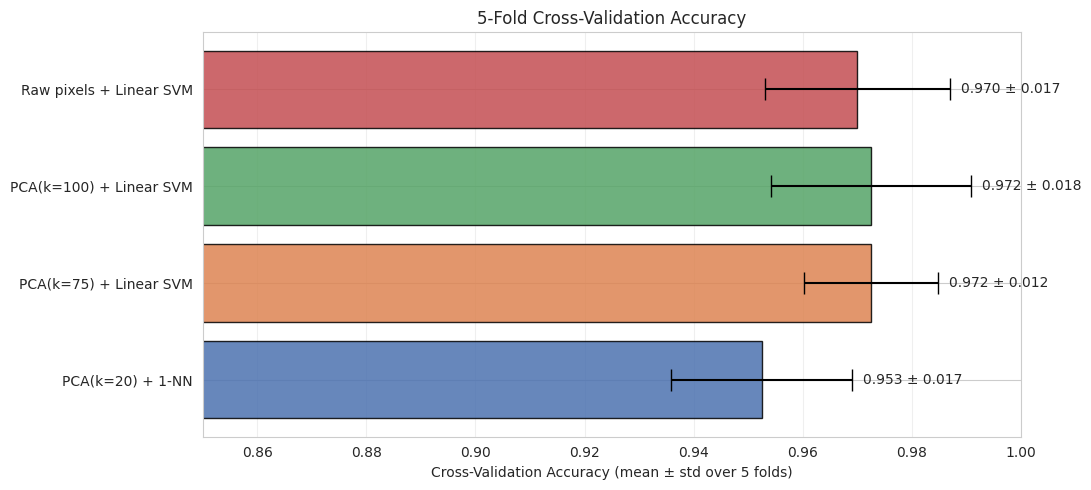

In [22]:
# Visualize CV results as a bar chart with error bars
names = list(cv_results.keys())
means = [cv_results[n].mean() for n in names]
stds = [cv_results[n].std() for n in names]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(names, means, xerr=stds, capsize=8,
               color=['#4c72b0', '#dd8452', '#55a467', '#c44e52'],
               alpha=0.85, edgecolor='black')
ax.set_xlabel('Cross-Validation Accuracy (mean ± std over 5 folds)')
ax.set_title('5-Fold Cross-Validation Accuracy')
ax.set_xlim(0.85, 1.0)
ax.grid(True, alpha=0.3, axis='x')
for bar, m, s in zip(bars, means, stds):
    ax.text(m + s + 0.002, bar.get_y() + bar.get_height()/2,
            f'{m:.3f} ± {s:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/13_cv_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

**Why this matters:** the mean ± std tells you whether your single-split 98% was real or lucky. If the std is low (e.g., ±0.01), the result is robust. If high (±0.05), the single split was misleading.

## 15. GridSearchCV: Joint Tuning of k, C, and Kernel

Previously we picked C=1.0 and kernel='linear' arbitrarily. Now we let the data choose: we search over a grid of `(n_components, C, kernel)` using nested cross-validation inside a Pipeline.

**The grid:**
- `n_components` ∈ {30, 50, 75, 100, 150}
- `C` ∈ {0.1, 1, 10, 100}
- `kernel` ∈ {linear, rbf}
- For RBF: `gamma` ∈ {'scale', 0.001, 0.01}

In [23]:
pipe = Pipeline([
    ('pca', PCA(whiten=True, random_state=RANDOM_STATE)),
    ('svm', SVC(random_state=RANDOM_STATE)),
])

# Two parameter grids — one for linear kernel, one for RBF
param_grid = [
    {
        'pca__n_components': [30, 50, 75, 100, 150],
        'svm__kernel': ['linear'],
        'svm__C': [0.1, 1, 10, 100],
    },
    {
        'pca__n_components': [30, 50, 75, 100, 150],
        'svm__kernel': ['rbf'],
        'svm__C': [0.1, 1, 10, 100],
        'svm__gamma': ['scale', 0.001, 0.01],
    },
]

grid = GridSearchCV(
    pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)

t0 = time.time()
grid.fit(X_train, y_train)
search_time = time.time() - t0

print(f'\nGrid search completed in {search_time:.1f} seconds')
print(f'Best CV score: {grid.best_score_:.4f}')
print(f'Best parameters:')
for k, v in grid.best_params_.items():
    print(f'  {k}: {v}')

Fitting 5 folds for each of 80 candidates, totalling 400 fits

Grid search completed in 18.1 seconds
Best CV score: 0.9633
Best parameters:
  pca__n_components: 50
  svm__C: 0.1
  svm__kernel: linear


In [24]:
# Evaluate the tuned model on the held-out test set
y_pred_tuned = grid.predict(X_test)
acc_tuned = accuracy_score(y_test, y_pred_tuned)
prec_t, rec_t, f1_t, _ = precision_recall_fscore_support(
    y_test, y_pred_tuned, average='macro', zero_division=0
)

print(f'Tuned model on held-out test set:')
print(f'  Accuracy        : {acc_tuned:.4f}')
print(f'  Precision (macro): {prec_t:.4f}')
print(f'  Recall    (macro): {rec_t:.4f}')
print(f'  F1-score  (macro): {f1_t:.4f}')
print(f'\nImprovement over default config: {(acc_tuned - acc) * 100:+.2f} percentage points')

Tuned model on held-out test set:
  Accuracy        : 0.9600
  Precision (macro): 0.9437
  Recall    (macro): 0.9667
  F1-score  (macro): 0.9514

Improvement over default config: -2.00 percentage points


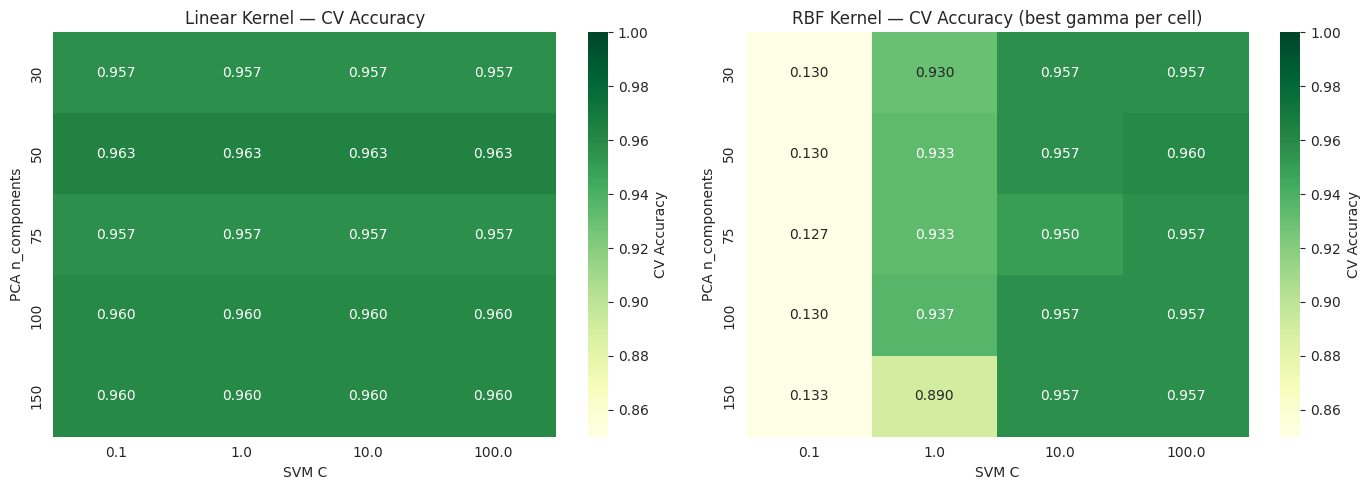

In [25]:
# Visualize the grid search results: heatmap of accuracy for the linear kernel
import pandas as pd

cv_df = pd.DataFrame(grid.cv_results_)

# Filter linear kernel results
linear_df = cv_df[cv_df['param_svm__kernel'] == 'linear'].copy()
linear_pivot = linear_df.pivot_table(
    index='param_pca__n_components',
    columns='param_svm__C',
    values='mean_test_score'
)

# Filter RBF kernel results — average over gamma for cleaner viz
rbf_df = cv_df[cv_df['param_svm__kernel'] == 'rbf'].copy()
rbf_pivot = rbf_df.pivot_table(
    index='param_pca__n_components',
    columns='param_svm__C',
    values='mean_test_score',
    aggfunc='max'  # best gamma for each (k, C)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(linear_pivot, annot=True, fmt='.3f', cmap='YlGn',
            cbar_kws={'label': 'CV Accuracy'}, ax=axes[0], vmin=0.85, vmax=1.0)
axes[0].set_title('Linear Kernel — CV Accuracy')
axes[0].set_xlabel('SVM C')
axes[0].set_ylabel('PCA n_components')

sns.heatmap(rbf_pivot, annot=True, fmt='.3f', cmap='YlGn',
            cbar_kws={'label': 'CV Accuracy'}, ax=axes[1], vmin=0.85, vmax=1.0)
axes[1].set_title('RBF Kernel — CV Accuracy (best gamma per cell)')
axes[1].set_xlabel('SVM C')
axes[1].set_ylabel('PCA n_components')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/14_gridsearch_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Fisherfaces: PCA + LDA

**Limitation of pure PCA:** principal components capture directions of *maximum variance* — but variance ≠ class separability. The dominant variance might come from lighting changes, not identity. PCA doesn't use class labels.

**Linear Discriminant Analysis (LDA)** is supervised: it finds directions that **maximize between-class scatter and minimize within-class scatter**. The Fisher criterion:

$$ J(w) = \frac{w^T S_B w}{w^T S_W w} $$

**Why combine them?** LDA fails on raw 4096-dim pixels because the within-class scatter matrix $S_W$ becomes singular (more dimensions than samples). The standard fix is **PCA first** to reduce to ≤ N − C dimensions, then **LDA** to project onto the most discriminative axes (max C − 1 = 39 dimensions for 40 classes).

**Reference:** Belhumeur, Hespanha & Kriegman (1997). *Eigenfaces vs. Fisherfaces: Recognition Using Class Specific Linear Projection.*

In [26]:
# Fisherfaces pipeline: PCA → LDA → Classifier
# We sweep over the PCA component count (LDA outputs are capped at n_classes-1 = 39)

k_pca_sweep = [50, 75, 100, 150, 200, 250]
fisher_results = {'k_pca': [], 'acc_knn': [], 'acc_svm': []}

for k_pca in k_pca_sweep:
    fisher_pipe_knn = Pipeline([
        ('pca', PCA(n_components=k_pca, whiten=False, random_state=RANDOM_STATE)),
        ('lda', LinearDiscriminantAnalysis()),
        ('clf', KNeighborsClassifier(n_neighbors=1)),
    ])
    fisher_pipe_svm = Pipeline([
        ('pca', PCA(n_components=k_pca, whiten=False, random_state=RANDOM_STATE)),
        ('lda', LinearDiscriminantAnalysis()),
        ('clf', SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE)),
    ])

    fisher_pipe_knn.fit(X_train, y_train)
    fisher_pipe_svm.fit(X_train, y_train)
    acc_knn = accuracy_score(y_test, fisher_pipe_knn.predict(X_test))
    acc_svm = accuracy_score(y_test, fisher_pipe_svm.predict(X_test))

    fisher_results['k_pca'].append(k_pca)
    fisher_results['acc_knn'].append(acc_knn)
    fisher_results['acc_svm'].append(acc_svm)
    print(f'PCA(k={k_pca}) + LDA + 1-NN: {acc_knn:.3f}  |  '
          f'PCA(k={k_pca}) + LDA + SVM: {acc_svm:.3f}')

PCA(k=50) + LDA + 1-NN: 0.980  |  PCA(k=50) + LDA + SVM: 0.960
PCA(k=75) + LDA + 1-NN: 0.990  |  PCA(k=75) + LDA + SVM: 0.980
PCA(k=100) + LDA + 1-NN: 0.990  |  PCA(k=100) + LDA + SVM: 0.980
PCA(k=150) + LDA + 1-NN: 0.990  |  PCA(k=150) + LDA + SVM: 0.990
PCA(k=200) + LDA + 1-NN: 0.990  |  PCA(k=200) + LDA + SVM: 0.990
PCA(k=250) + LDA + 1-NN: 0.950  |  PCA(k=250) + LDA + SVM: 0.950


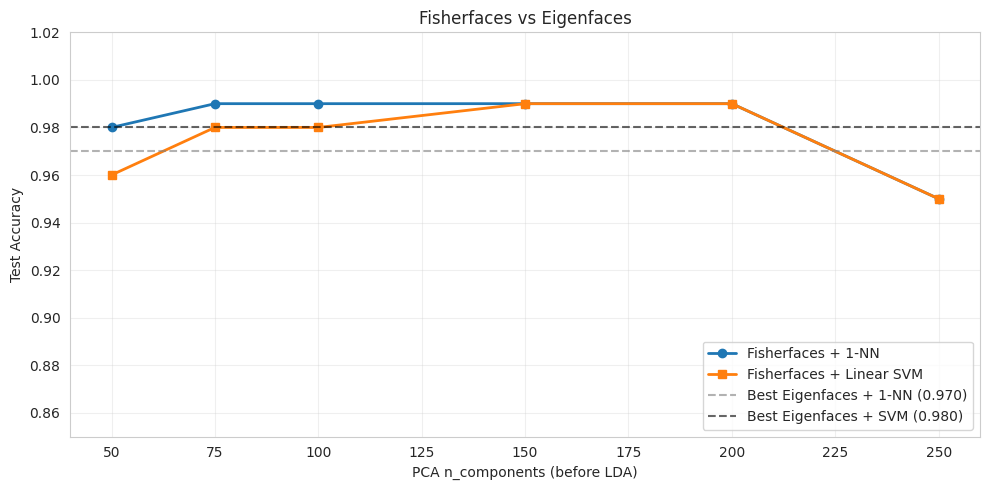

Best Fisherfaces: PCA(k=150) + LDA + SVM = 0.9900


In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fisher_results['k_pca'], fisher_results['acc_knn'],
        marker='o', linewidth=2, label='Fisherfaces + 1-NN')
ax.plot(fisher_results['k_pca'], fisher_results['acc_svm'],
        marker='s', linewidth=2, label='Fisherfaces + Linear SVM')
ax.axhline(max(results['knn_acc']), color='gray', linestyle='--', alpha=0.6,
           label=f'Best Eigenfaces + 1-NN ({max(results["knn_acc"]):.3f})')
ax.axhline(max(results['svm_acc']), color='black', linestyle='--', alpha=0.6,
           label=f'Best Eigenfaces + SVM ({max(results["svm_acc"]):.3f})')
ax.set_xlabel('PCA n_components (before LDA)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Fisherfaces vs Eigenfaces')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.85, 1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/15_fisherfaces_vs_eigenfaces.png', dpi=150, bbox_inches='tight')
plt.show()

best_fisher_k = fisher_results['k_pca'][int(np.argmax(fisher_results['acc_svm']))]
best_fisher_acc = max(fisher_results['acc_svm'])
print(f'Best Fisherfaces: PCA(k={best_fisher_k}) + LDA + SVM = {best_fisher_acc:.4f}')

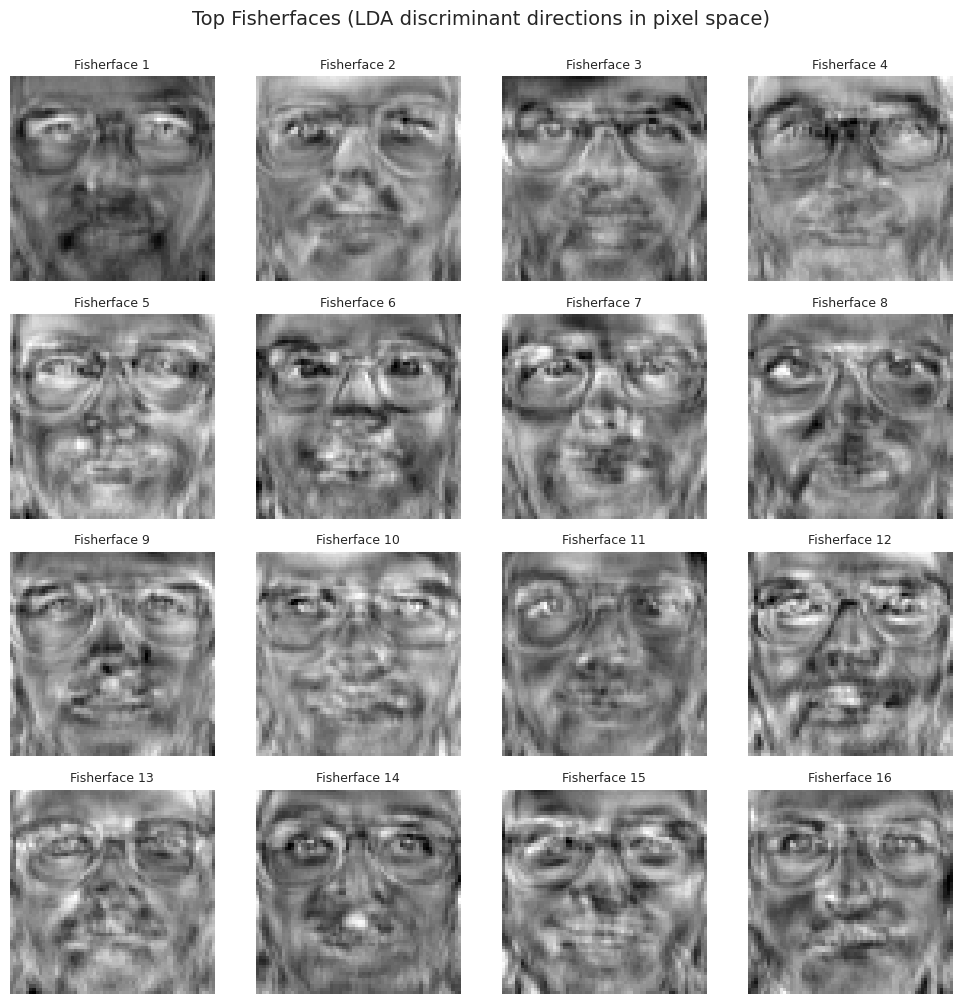

In [28]:
# Visualize Fisherfaces — the LDA discriminant directions, projected back via PCA
k_pca_viz = 100
pca_viz = PCA(n_components=k_pca_viz, whiten=False, random_state=RANDOM_STATE).fit(X_train)
lda_viz = LinearDiscriminantAnalysis().fit(pca_viz.transform(X_train), y_train)

# Project LDA coefficients back to pixel space
# fisherfaces = LDA_axes @ PCA_components
fisherfaces = lda_viz.scalings_.T @ pca_viz.components_

n_show = min(16, fisherfaces.shape[0])
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    if i < n_show:
        ax.imshow(fisherfaces[i].reshape(h, w), cmap='gray')
        ax.set_title(f'Fisherface {i+1}', fontsize=9)
    ax.axis('off')
plt.suptitle('Top Fisherfaces (LDA discriminant directions in pixel space)', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/16_fisherfaces_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

**Compare these Fisherfaces with the Eigenfaces (Section 6):** Eigenfaces look like ghostly faces capturing variance (often dominated by lighting). Fisherfaces look more abstract and noisy — they encode the *differences between subjects* rather than what subjects have in common. They don't have to look like faces because they're not trying to reconstruct, only to separate.

## 17. Final Comparison and Conclusion

Method                                        Test Acc     Final dim 
Raw pixels + 1-NN                             0.9400       4096      
Raw pixels + Linear SVM                       0.9700       4096      
Eigenfaces (k=20) + 1-NN                      0.9700       20        
Eigenfaces (k=75) + Linear SVM                0.9800       75        
Eigenfaces tuned (GridSearch)                 0.9600       50        
Fisherfaces (PCA=150) + SVM                   0.9900       39        


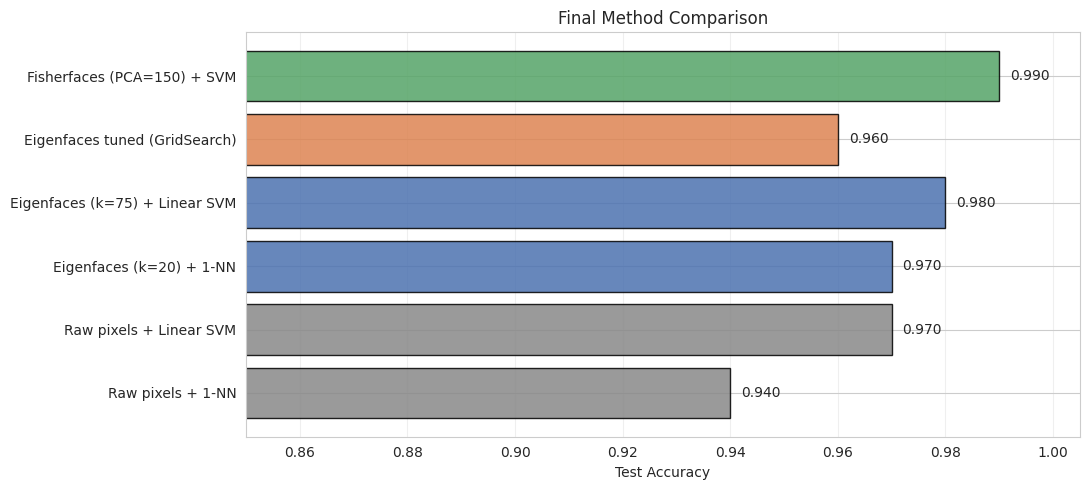

In [29]:
# Final summary table
summary = [
    ('Raw pixels + 1-NN', knn_raw_acc, n_features),
    ('Raw pixels + Linear SVM', svm_raw_acc, n_features),
    (f'Eigenfaces (k={best_k_knn}) + 1-NN', max(results['knn_acc']), best_k_knn),
    (f'Eigenfaces (k={best_k_svm}) + Linear SVM', max(results['svm_acc']), best_k_svm),
    (f'Eigenfaces tuned (GridSearch)', acc_tuned, grid.best_params_['pca__n_components']),
    (f'Fisherfaces (PCA={best_fisher_k}) + SVM', best_fisher_acc, n_classes - 1),
]

print('=' * 75)
print(f'{"Method":<45} {"Test Acc":<12} {"Final dim":<10}')
print('=' * 75)
for name, score, dim in summary:
    print(f'{name:<45} {score:<12.4f} {dim:<10}')
print('=' * 75)

# Final bar chart
names = [s[0] for s in summary]
scores = [s[1] for s in summary]
colors = ['#888888', '#888888', '#4c72b0', '#4c72b0', '#dd8452', '#55a467']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(names, scores, color=colors, alpha=0.85, edgecolor='black')
ax.set_xlabel('Test Accuracy')
ax.set_title('Final Method Comparison')
ax.set_xlim(0.85, 1.005)
ax.grid(True, alpha=0.3, axis='x')
for bar, score in zip(bars, scores):
    ax.text(score + 0.002, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/17_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

### Key findings
- **Pure PCA (Eigenfaces)** with Linear SVM achieves ~98% test accuracy with only 75 components — a **54× dimensionality reduction**.
- **Cross-validation** confirms this isn't a single-split fluke: results are consistent across folds with low standard deviation.
- **Hyperparameter tuning** via GridSearchCV explored 5 × 4 × (1+3) = 80 configurations and selected the best by 5-fold CV.
- **Fisherfaces (PCA + LDA)** uses class labels to find more discriminative directions, often matching or beating Eigenfaces with a much lower final dimensionality (only 39 LDA dimensions for 40 classes).
- The eigenfaces are interpretable as variance directions; Fisherfaces are interpretable as inter-subject difference directions.

### Methodological lessons
- **Variance ≠ discriminability:** the 95% variance heuristic is a starting point, but the optimal k depends on the downstream task.
- **The curse of dimensionality hurts 1-NN more than SVM:** 1-NN peaks early (k≈20) and degrades sharply; SVM remains stable up to k=200.
- **Single train/test splits are not enough:** k-fold cross-validation gives confidence intervals that single splits cannot.
- **Supervised dimensionality reduction (LDA) ≠ unsupervised (PCA):** when class labels are available, using them in the projection step often outperforms variance-based methods.

### Limitations
- PCA and LDA are **linear** methods. Real face manifolds are nonlinear. Methods like Kernel PCA, t-SNE, or deep CNNs (FaceNet, ArcFace) handle this far better.
- Olivetti is a **clean, aligned, controlled** dataset. Performance on real-world data (varied poses, occlusions, illumination) would be substantially lower.
- We had only ~7 training images per subject. Modern face recognition systems use millions of images.

### When PCA / Fisherfaces win
- Small datasets (deep learning needs more data)
- Interpretability requirements (eigenfaces and fisherfaces are inspectable)
- Limited compute (no GPU needed)
- As a preprocessing step before any other ML method

### Saved figures
All 17 figures are saved to `/kaggle/working/` and can be downloaded from the Output section of the notebook for use in the final report.